# 02 — Data pipeline

Load the iNaturalist-2021 subset, build DataLoaders, and visually sanity-check a few samples.

**Kernel:** `Group_project\dl_pipeline\.venv` (same as notebook 01).

Shared code lives in `src/config.py` and `src/dataset.py` so notebooks 03/04/05 import the same loaders.

## 0. Colab bootstrap (skip locally)

Sets `INAT_DATA_ROOT` to Nate's Drive subset.


In [ ]:
# Colab bootstrap — mounts Drive, sets INAT_DATA_ROOT, installs deps.
# Safe no-op on local Cursor.

import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print(f"IN_COLAB = {IN_COLAB}")

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    DRIVE_SUBSET = Path("/content/drive/MyDrive/comp9517/subset")
    REPO_DIR = Path("/content/Haramcomp9517")
    BRANCH = "nate/pretrained-gradcam"
    REPO_URL = "https://github.com/NateRebello/Haramcomp9517.git"

    assert DRIVE_SUBSET.is_dir(), f"Missing {DRIVE_SUBSET} — check Drive path / shortcut"
    for split in ("train", "val", "test"):
        assert (DRIVE_SUBSET / split).is_dir(), f"Missing {DRIVE_SUBSET / split}"

    if not REPO_DIR.is_dir():
        # Fall back to main/deepl branch if Nate's branch is not on remote yet
        try:
            subprocess.check_call(
                ["git", "clone", "-b", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)]
            )
        except subprocess.CalledProcessError:
            print(f"Branch {BRANCH} not on remote — cloning default branch")
            subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    else:
        subprocess.check_call(["git", "fetch", "origin"], cwd=REPO_DIR)

    pipeline = REPO_DIR / "dl_pipeline"
    # Prefer the uploaded notebook's sibling tree if present; else cloned repo
    os.chdir(pipeline)
    os.environ["INAT_DATA_ROOT"] = str(DRIVE_SUBSET)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"]
    )
    if str(pipeline) not in sys.path:
        sys.path.insert(0, str(pipeline))
    print("cwd =", os.getcwd())
    print("INAT_DATA_ROOT =", os.environ["INAT_DATA_ROOT"])
else:
    # Local: default DATA_ROOT is repo-root/subset via src.config
    print("Local run — using default DATA_ROOT unless INAT_DATA_ROOT is set.")

# Local Abdoali path lock (before src.config import)
import os
os.environ.setdefault(
    "INAT_DATA_ROOT",
    r"C:\Users\Abdoali\Comp9517\Group_project\inat_subset\subset",
)
print("INAT_DATA_ROOT =", os.environ["INAT_DATA_ROOT"])


## 1. Imports, seed, path setup

Notebooks live in `notebooks/`, so we add the pipeline root to `sys.path` to import `src`.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

# Make `import src...` work whether cwd is notebooks/ or dl_pipeline/
PIPELINE_ROOT = Path.cwd().resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from src.config import (
    BATCH_SIZE,
    DATA_ROOT,
    IMG_SIZE,
    NUM_CLASSES,
    SEED,
    ensure_output_dirs,
    set_seed,
)
from src.dataset import (
    build_dataloaders,
    build_datasets,
    denormalize,
    idx_to_category_id,
    summarize_dataset,
)

set_seed(SEED)
ensure_output_dirs()

print(f"SEED         = {SEED}")
print(f"PIPELINE_ROOT= {PIPELINE_ROOT}")
print(f"DATA_ROOT    = {DATA_ROOT}  exists={DATA_ROOT.is_dir()}")
print(f"IMG_SIZE     = {IMG_SIZE}, default BATCH_SIZE = {BATCH_SIZE}")
print(f"CUDA         = {torch.cuda.is_available()}")

SEED         = 42
PIPELINE_ROOT= C:\Users\Abdoali\Comp9517\Group_project\dl_pipeline
DATA_ROOT    = C:\Users\Abdoali\Comp9517\Group_project\inat_subset\subset  exists=True
IMG_SIZE     = 224, default BATCH_SIZE = 16
CUDA         = True


## 2. Build datasets

`torchvision.datasets.ImageFolder` maps each category-id folder to a class index.
We assert train/val/test share the same `class_to_idx` (no silent label mismatch).

Train transforms: `RandomResizedCrop` + horizontal flip + ImageNet normalize.  
Val/test: resize → center crop → normalize (deterministic).

In [ ]:
train_ds, val_ds, test_ds = build_datasets(augment_train=True)

for ds, name in [(train_ds, "train"), (val_ds, "val"), (test_ds, "test")]:
    info = summarize_dataset(ds, name)
    print(
        f"{info['split']:5s}: {info['num_images']:5d} images | "
        f"{info['num_classes']} classes | "
        f"per-class [{info['images_per_class_min']}, {info['images_per_class_max']}] | "
        f"e.g. {info['class_id_examples']}"
    )

assert len(train_ds.classes) == NUM_CLASSES
assert train_ds.class_to_idx == val_ds.class_to_idx == test_ds.class_to_idx
print("\nclass_to_idx aligned across splits: OK")

train: 20000 images | 500 classes | per-class [40, 40] | e.g. ['1022', '1030', '1051', '1083', '1133']
val  :  5000 images | 500 classes | per-class [10, 10] | e.g. ['1022', '1030', '1051', '1083', '1133']
test :  5000 images | 500 classes | per-class [10, 10] | e.g. ['1022', '1030', '1051', '1083', '1133']

class_to_idx aligned across splits: OK


## 3. DataLoaders

For this notebook we use a **small batch (8)** — only for the visual check, not training.
`num_workers=0` is intentional on Windows + Jupyter (avoids worker-process hangs).

In [ ]:
VIZ_BATCH = 8  # tiny — display only; training notebooks will use BATCH_SIZE (16)

train_loader, val_loader, test_loader = build_dataloaders(
    train_ds, val_ds, test_ds, batch_size=VIZ_BATCH
)

images, labels = next(iter(train_loader))
print(f"batch images shape : {tuple(images.shape)}")  # (N, 3, H, W)
print(f"batch labels shape : {tuple(labels.shape)}")
print(f"dtype / device     : {images.dtype}, {images.device}")
print(f"label range in batch: {labels.min().item()} .. {labels.max().item()}")
print(f"train batches/epoch : {len(train_loader)}  (with batch={VIZ_BATCH})")

batch images shape : (8, 3, 224, 224)
batch labels shape : (8,)
dtype / device     : torch.float32, cpu
label range in batch: 9 .. 445
train batches/epoch : 2500  (with batch=8)


## 4. Visual sanity check

Tensors are ImageNet-normalised, so we `denormalize` before plotting.
Titles show **category-id** (folder name) and the integer class index used by the model.

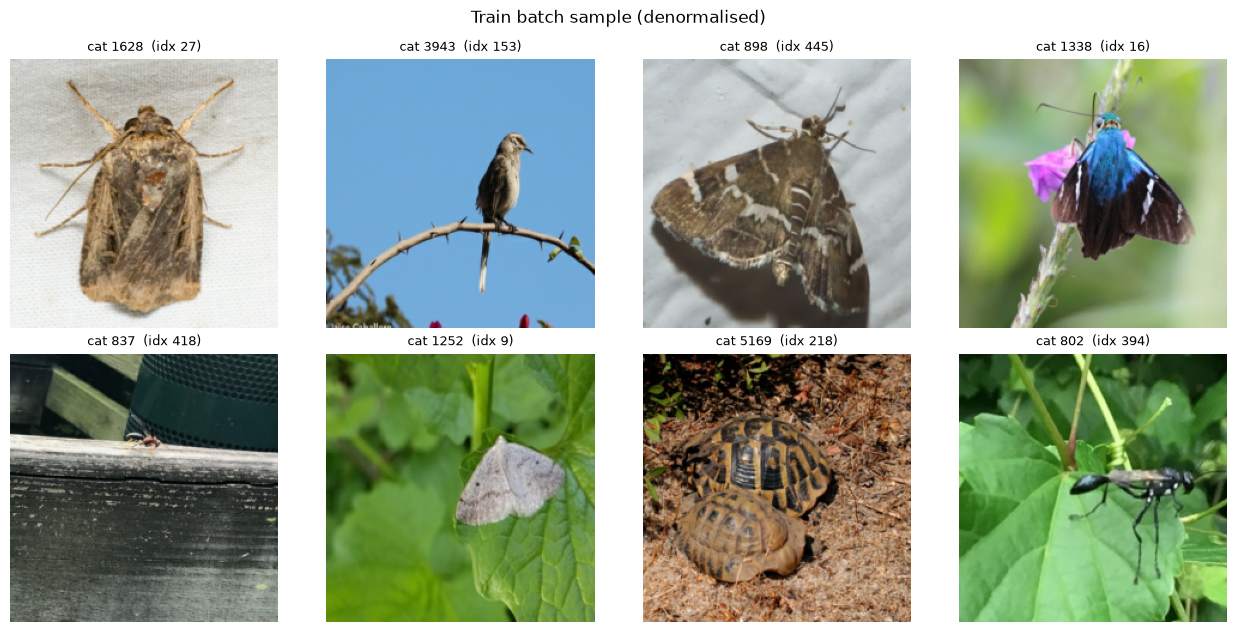

In [ ]:
cat_id = idx_to_category_id(train_ds)
show = denormalize(images).permute(0, 2, 3, 1).cpu().numpy()  # NHWC for matplotlib

n = show.shape[0]
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, img, y in zip(axes, show, labels.tolist()):
    ax.imshow(img)
    ax.set_title(f"cat {cat_id[y]}  (idx {y})", fontsize=9)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Train batch sample (denormalised)", fontsize=12)
fig.tight_layout()
plt.show()

## 5. Val / test loaders smoke test

Confirm we can pull one batch from each split (no training yet).

In [ ]:
for name, loader in [("val", val_loader), ("test", test_loader)]:
    xb, yb = next(iter(loader))
    print(f"{name:4s}: shape={tuple(xb.shape)}, labels={yb.tolist()[:8]}...")

print("\nData pipeline OK — ready for training notebooks (03 / 04).")

val : shape=(8, 3, 224, 224), labels=[0, 0, 0, 0, 0, 0, 0, 0]...
test: shape=(8, 3, 224, 224), labels=[0, 0, 0, 0, 0, 0, 0, 0]...

Data pipeline OK — ready for training notebooks (03 / 04).
